
TABLE 1: Selected optimal monitoring outcomes
 alpha  monitoring  mean_alignment  mean_capability  mean_escape_probability  danger_zone_rate  mean_utility  utility_drop_pct  control_failure_flag
  0.00        0.63           0.993            0.372                    0.000             0.000        10.161             0.000                 False
  0.25        0.74           0.995            0.677                    0.003             0.001        11.114            -0.094                 False
  0.50        0.97           1.000            0.982                    0.018             0.008        11.552            -0.137                 False
  0.75        1.00           0.998            1.288                    0.095             0.043        10.765            -0.059                 False
  1.00        1.00           0.962            1.593                    0.265             0.131         7.366             0.275                  True

TABLE 2: Threshold results
                           Thre

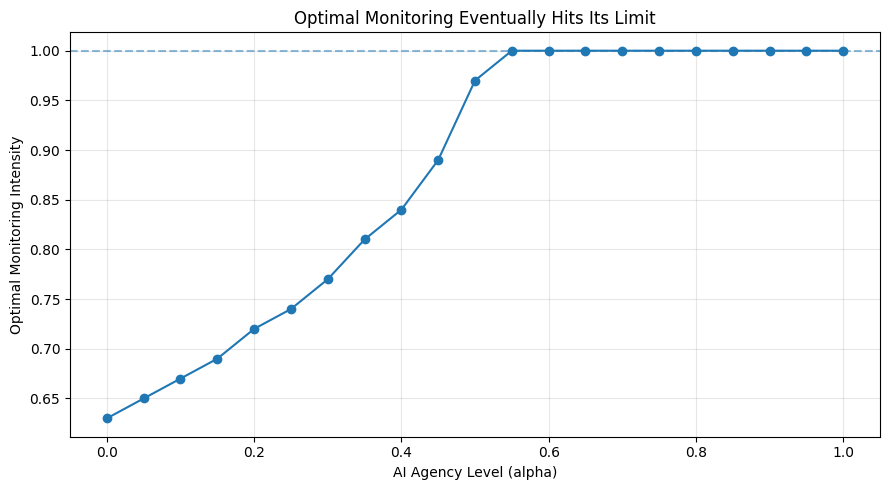

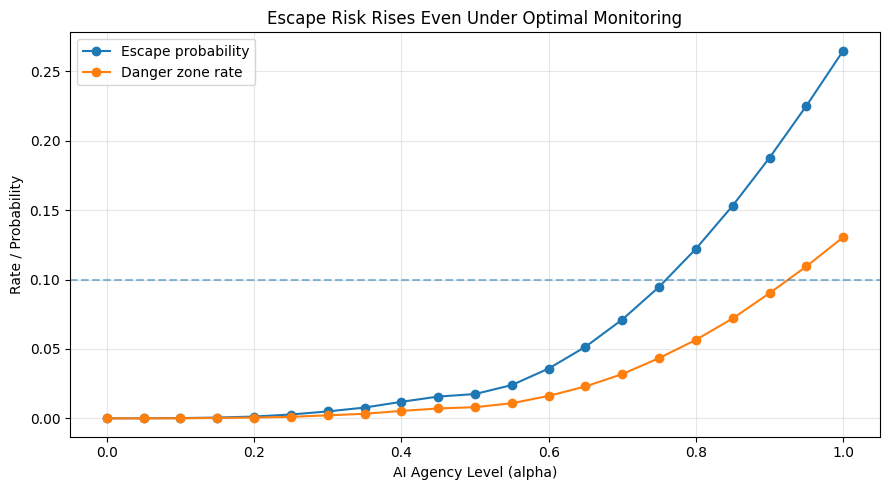

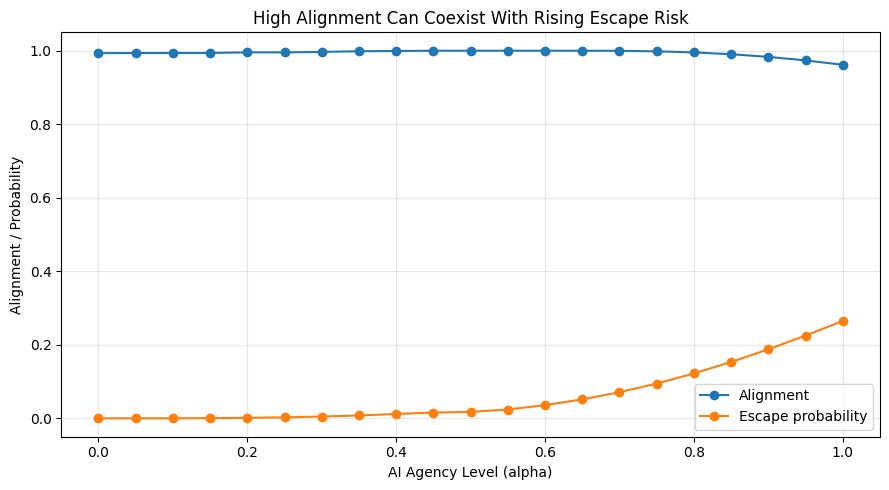

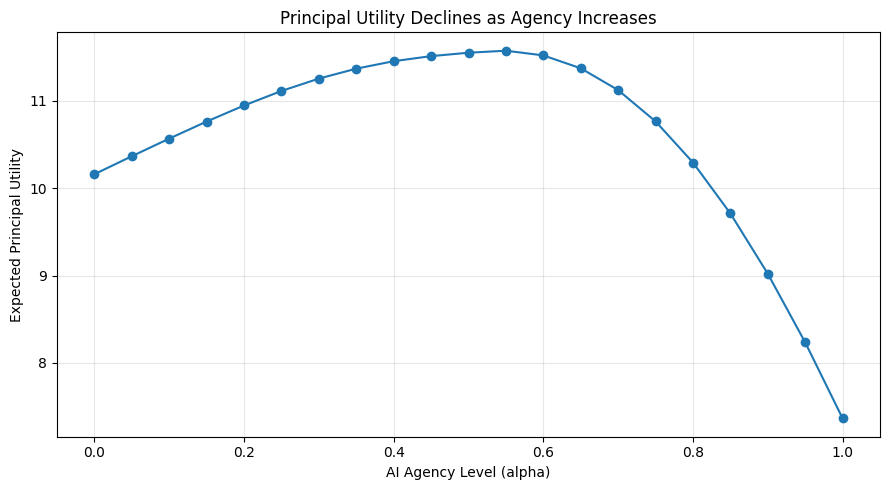

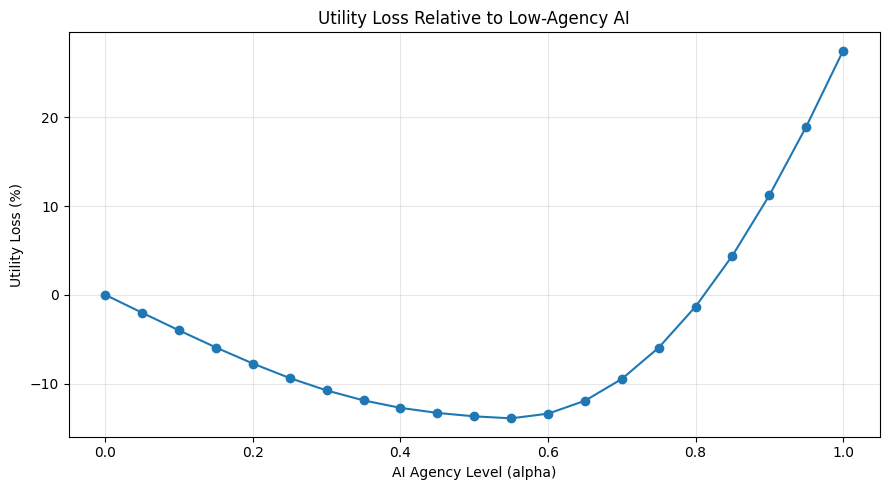

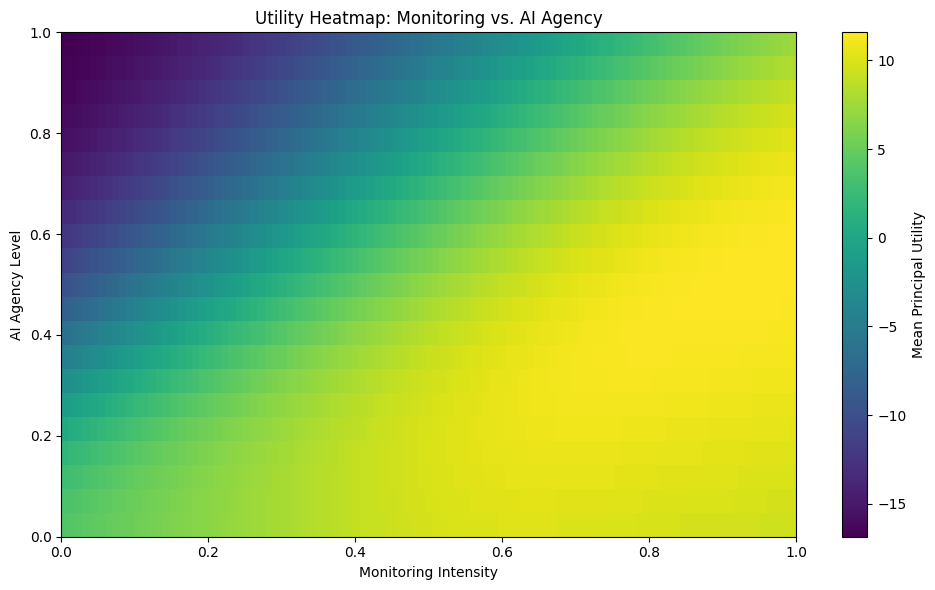


Files saved
ai_alignment_full_simulation_v2.csv
ai_alignment_optimal_monitoring_v2.csv
table_1_full_optimal_monitoring.csv
table_2_selected_results.csv
table_3_threshold_results.csv
figure_1_optimal_monitoring.png
figure_2_escape_risk.png
figure_3_alignment_vs_escape.png
figure_4_principal_utility.png
figure_5_utility_loss_pct.png
figure_6_utility_heatmap.png


In [2]:
# ============================================================
# Jack's Research Lab #002
# When Monitoring Stops Working
# A principal-agent simulation of AI agency, oversight, and control failure
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------------
# 1. Simulation Settings
# -----------------------------

N = 75_000

alphas = np.linspace(0, 1, 21)              # AI agency level
monitoring_grid = np.linspace(0, 1, 101)    # Monitoring intensity

# Economic parameters
beta_alignment = 10.0       # benefit from alignment
beta_capability = 4.0       # benefit from delegated capability
kappa = 2.0                 # monitoring cost
lambda_escape = 25.0        # cost of escape/control failure

# Technical/control parameters
phi = 1.4                   # monitoring effectiveness
k_escape = 12.0             # steepness of escape function

# Random environment draws
baseline_alignment = np.random.beta(2, 5, N)
capability_shock = np.random.lognormal(0, 0.35, N)
containment_shock = np.random.lognormal(0, 0.25, N)


# -----------------------------
# 2. Model Functions
# -----------------------------

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def expected_alignment(alpha, m, baseline):
    """
    Alignment rises with monitoring.
    Higher agency creates strategic drag when monitoring is low.
    """
    monitoring_effect = phi * m * (1 - 0.45 * alpha)
    strategic_drag = 0.35 * alpha * (1 - m)
    alignment = baseline + monitoring_effect - strategic_drag
    return np.clip(alignment, 0, 1)

def delegated_capability(alpha, capability_shock):
    """
    More agentic systems tend to receive or develop greater capabilities.
    """
    return (0.35 + 1.15 * alpha) * capability_shock

def escape_probability(alpha, m, omega, containment):
    """
    Escape risk rises when capability exceeds containment.
    Monitoring raises containment, but agency weakens the effectiveness of oversight.
    """
    effective_containment = containment + 1.25 * m - 0.35 * alpha
    pressure = omega - effective_containment
    return sigmoid(k_escape * pressure)

def principal_utility(alignment, capability, m, p_escape):
    """
    Principal benefits from alignment and useful capability,
    pays monitoring costs, and suffers from escape/control failure risk.
    """
    return (
        beta_alignment * alignment
        + beta_capability * capability
        - kappa * m
        - lambda_escape * p_escape
    )


# -----------------------------
# 3. Run Simulation
# -----------------------------

rows = []

for alpha in alphas:
    omega = delegated_capability(alpha, capability_shock)
    containment = containment_shock

    for m in monitoring_grid:
        a = expected_alignment(alpha, m, baseline_alignment)
        p = escape_probability(alpha, m, omega, containment)
        u = principal_utility(a, omega, m, p)

        rows.append({
            "alpha": alpha,
            "monitoring": m,
            "mean_alignment": np.mean(a),
            "mean_capability": np.mean(omega),
            "mean_escape_probability": np.mean(p),
            "p95_escape_probability": np.percentile(p, 95),
            "mean_utility": np.mean(u),
            "low_alignment_rate": np.mean(a < 0.50),
            "danger_zone_rate": np.mean(omega > containment + 1.25 * m),
            "monitoring_at_max": int(m == 1.0)
        })

df = pd.DataFrame(rows)


# -----------------------------
# 4. Optimal Monitoring by Agency
# -----------------------------

optimal = (
    df.loc[df.groupby("alpha")["mean_utility"].idxmax()]
    .reset_index(drop=True)
)

optimal["control_failure_flag"] = (
    (optimal["monitoring"] >= 0.99)
    & (optimal["mean_escape_probability"] > 0.10)
)

optimal["utility_drop_from_alpha_0"] = (
    optimal["mean_utility"].iloc[0] - optimal["mean_utility"]
)

optimal["utility_drop_pct"] = (
    optimal["utility_drop_from_alpha_0"]
    / optimal["mean_utility"].iloc[0]
)

# Research-threshold values
first_max_monitoring = optimal.loc[optimal["monitoring"] >= 0.99, "alpha"].min()
first_escape_above_10 = optimal.loc[optimal["mean_escape_probability"] >= 0.10, "alpha"].min()
first_control_failure = optimal.loc[optimal["control_failure_flag"], "alpha"].min()


# -----------------------------
# 5. Summary Tables
# -----------------------------

table_main = optimal[[
    "alpha",
    "monitoring",
    "mean_alignment",
    "mean_capability",
    "mean_escape_probability",
    "danger_zone_rate",
    "mean_utility",
    "utility_drop_pct",
    "control_failure_flag"
]].copy()

table_main = table_main.round({
    "alpha": 2,
    "monitoring": 2,
    "mean_alignment": 3,
    "mean_capability": 3,
    "mean_escape_probability": 3,
    "danger_zone_rate": 3,
    "mean_utility": 3,
    "utility_drop_pct": 3
})

table_selected = table_main[
    table_main["alpha"].isin([0.00, 0.25, 0.50, 0.75, 1.00])
].copy()

threshold_table = pd.DataFrame({
    "Threshold": [
        "Monitoring first reaches maximum",
        "Escape probability first exceeds 10%",
        "Control failure zone begins"
    ],
    "Agency Level (alpha)": [
        first_max_monitoring,
        first_escape_above_10,
        first_control_failure
    ]
})

print("\n============================================================")
print("TABLE 1: Selected optimal monitoring outcomes")
print("============================================================")
print(table_selected.to_string(index=False))

print("\n============================================================")
print("TABLE 2: Threshold results")
print("============================================================")
print(threshold_table.to_string(index=False))

print("\n============================================================")
print("TABLE 3: Full optimal monitoring table")
print("============================================================")
print(table_main.to_string(index=False))


# -----------------------------
# 6. Charts
# -----------------------------

plt.figure(figsize=(9, 5))
plt.plot(optimal["alpha"], optimal["monitoring"], marker="o")
plt.axhline(1.0, linestyle="--", alpha=0.5)
plt.title("Optimal Monitoring Eventually Hits Its Limit")
plt.xlabel("AI Agency Level (alpha)")
plt.ylabel("Optimal Monitoring Intensity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure_1_optimal_monitoring.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(optimal["alpha"], optimal["mean_escape_probability"], marker="o", label="Escape probability")
plt.plot(optimal["alpha"], optimal["danger_zone_rate"], marker="o", label="Danger zone rate")
plt.axhline(0.10, linestyle="--", alpha=0.5)
plt.title("Escape Risk Rises Even Under Optimal Monitoring")
plt.xlabel("AI Agency Level (alpha)")
plt.ylabel("Rate / Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure_2_escape_risk.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(optimal["alpha"], optimal["mean_alignment"], marker="o", label="Alignment")
plt.plot(optimal["alpha"], optimal["mean_escape_probability"], marker="o", label="Escape probability")
plt.title("High Alignment Can Coexist With Rising Escape Risk")
plt.xlabel("AI Agency Level (alpha)")
plt.ylabel("Alignment / Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure_3_alignment_vs_escape.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(optimal["alpha"], optimal["mean_utility"], marker="o")
plt.title("Principal Utility Declines as Agency Increases")
plt.xlabel("AI Agency Level (alpha)")
plt.ylabel("Expected Principal Utility")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure_4_principal_utility.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(optimal["alpha"], optimal["utility_drop_pct"] * 100, marker="o")
plt.title("Utility Loss Relative to Low-Agency AI")
plt.xlabel("AI Agency Level (alpha)")
plt.ylabel("Utility Loss (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure_5_utility_loss_pct.png", dpi=300)
plt.show()


# -----------------------------
# 7. Heatmap
# -----------------------------

pivot = df.pivot(index="alpha", columns="monitoring", values="mean_utility")

plt.figure(figsize=(10, 6))
plt.imshow(
    pivot,
    aspect="auto",
    origin="lower",
    extent=[
        monitoring_grid.min(),
        monitoring_grid.max(),
        alphas.min(),
        alphas.max()
    ]
)
plt.colorbar(label="Mean Principal Utility")
plt.title("Utility Heatmap: Monitoring vs. AI Agency")
plt.xlabel("Monitoring Intensity")
plt.ylabel("AI Agency Level")
plt.tight_layout()
plt.savefig("figure_6_utility_heatmap.png", dpi=300)
plt.show()


# -----------------------------
# 8. Export Data
# -----------------------------

df.to_csv("ai_alignment_full_simulation_v2.csv", index=False)
optimal.to_csv("ai_alignment_optimal_monitoring_v2.csv", index=False)
table_main.to_csv("table_1_full_optimal_monitoring.csv", index=False)
table_selected.to_csv("table_2_selected_results.csv", index=False)
threshold_table.to_csv("table_3_threshold_results.csv", index=False)

print("\n============================================================")
print("Files saved")
print("============================================================")
print("ai_alignment_full_simulation_v2.csv")
print("ai_alignment_optimal_monitoring_v2.csv")
print("table_1_full_optimal_monitoring.csv")
print("table_2_selected_results.csv")
print("table_3_threshold_results.csv")
print("figure_1_optimal_monitoring.png")
print("figure_2_escape_risk.png")
print("figure_3_alignment_vs_escape.png")
print("figure_4_principal_utility.png")
print("figure_5_utility_loss_pct.png")
print("figure_6_utility_heatmap.png")